In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob
from time import time
import os
from dataclasses import replace
from RaTag.core.datatypes import Run, SetPmt, S2Areas
from RaTag.core.config import TimingConfig, IntegrationConfig, FitConfig
from RaTag.core.wfm2read_fast import wfm2read
from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.alphas.alphas_workflow import map_alpha_events
from RaTag.thgem_tpc.drift_workflow import map_drift_physics
from RaTag.thgem_tpc.timing_workflow import map_time_windows, resolve_set_timing, map_timing_plots
from RaTag.thgem_tpc.recoil_workflow import map_recoil_integration, map_recoil_fits, map_recoil_plots
from RaTag.thgem_tpc.coincidence_workflow import map_coincidence_extraction
from RaTag.thgem_tpc.multiiso_workflow import map_multiiso_separation, map_multiiso_s2_vs_field

%matplotlib inline

# Initialize test run and drift properties

In [3]:
config_path = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run35_analysis.yaml'

run = bootstrap_from_config(config_path)

Found 10 directories in RUN35_EL20kVcm
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0120_Anode0920 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0156_Anode0956 with 20 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0188_Anode0988 with 33 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0216_Anode1016 with 20 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0288_Anode1088 with 20 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0384_Anode1184 with 20 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0480_Anode1280 with 20 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0576_Anode1376 with 20 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0672_Anode1472 with 20 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0768_Anode1568 with 20 waveforms.
  → Bootstrapped 10 PMT Sets and 10 Alpha Sets. (Multi-Isotope: True)


In [4]:
run = map_drift_physics(run, force=False)

  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0120_Anode0920'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0120_Anode0920'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0120_Anode0920'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0156_Anode0956'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0156_Anode0956'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0156_Anode0956'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0188_Anode0988'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0188_Anode0988'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0188_Anode0988'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0216_Anode1016'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0216_Anode1016'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0216_Anode1016'
  📂 Cache Hit: Loaded metada

In [5]:
run = map_alpha_events(run, force=False)


RECONSTRUCTING ALPHA ENERGIES: RUN_35
Force flag: False
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0120_Anode0920'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0156_Anode0956'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0188_Anode0988'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0216_Anode1016'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0288_Anode1088'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0384_Anode1184'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0480_Anode1280'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0576_Anode1376'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0672_Anode1472'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0768_Anode1568'


In [6]:
run = map_coincidence_extraction(run, force=False)


EXTRACTING COINCIDENCE DATA: RUN_35
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0120_Anode0920'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0156_Anode0956'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0188_Anode0988'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0216_Anode1016'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0288_Anode1088'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0384_Anode1184'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0480_Anode1280'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0576_Anode1376'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0672_Anode1472'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0768_Anode1568'


In [7]:
runm = map_multiiso_separation(run, force=True)


SEPARATING MULTI-ISOTOPE SETS: RUN_35

  Mapping FieldScan_Gate0120_Anode0920...
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/s2_areas/FieldScan_Gate0120_Anode0920_s2_areas.npz
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/alpha_energies/FieldScan_Gate0120_Anode0920_alpha_energies.npz
    ✓ Separated Th228: 174072 events
    ✓ Separated Ra224: 162399 events
    ✓ Separated Bi212: 88826 events
    ✓ Separated Rn220: 106398 events
    ✓ Separated Po216: 111073 events
    ✓ Separated Po212: 71290 events

  Mapping FieldScan_Gate0156_Anode0956...
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/s2_areas/FieldScan_Gate0156_Anode0956_s2_areas.npz
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/alpha_energies/FieldScan_Gate0156_Anode0956_alpha_energies.npz
    ✓ Separated Th228: 11554 events
    ✓ Separated Ra224: 10416 events

In [8]:
for iso, iso_run in runm.items():
    fitted_run = map_recoil_fits(iso_run, force=True)
    runm[iso] = fitted_run  # Update the dict with the fitted run
    plotted_run = map_recoil_plots(fitted_run)


FITTING S2 AREA DISTRIBUTIONS: RUN_35_Th228
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/isotope_areas/Th228/FieldScan_Gate0120_Anode0920_Th228_s2_areas.npz
  Fit success: True, χ²/DOF: 28.29
  ✓ Fit: μ=9.733 ± 0.368 mV·µs
  ✓ FieldScan_Gate0120_Anode0920_Th228: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/isotope_areas/Th228/FieldScan_Gate0156_Anode0956_Th228_s2_areas.npz
  Fit success: True, χ²/DOF: 0.91
  ✓ Fit: μ=8.185 ± 0.482 mV·µs
  ✓ FieldScan_Gate0156_Anode0956_Th228: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/isotope_areas/Th228/FieldScan_Gate0188_Anode0988_Th228_s2_areas.npz
  Fit success: True, χ²/DOF: 3.00
  ✓ Fit: μ=10.626 ± 0.761 mV·µs
  ✓ FieldScan_Gate0188_Anode0988_Th228: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arra

In [9]:
run = map_multiiso_s2_vs_field(run, spawned_runs=runm, force=True)


PLOTTING MULTI-ISOTOPE S2 VS FIELD: RUN_35
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/plots/s2_areas/multi/RUN_35_s2_vs_field_multiiso.png


In [13]:
runm['Ra224'].sets[6].area_s2_mean

10.62287854755214

In [12]:
runm['Po212'].sets[6].area_s2_mean

10.623678925374458

In [25]:
set6 = run.sets[6]
s2_areas = load_s2areas(set6)

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/s2_areas/FieldScan_Gate0480_Anode1280_s2_areas.npz


In [27]:
s2_areas

S2Areas(uids=array([  65,   68,   69, ..., 2253, 2259, 2262]), areas=array([1.29925449, 0.98648967, 2.22679696, ..., 1.4565153 , 0.92353287,
       2.8724546 ]))

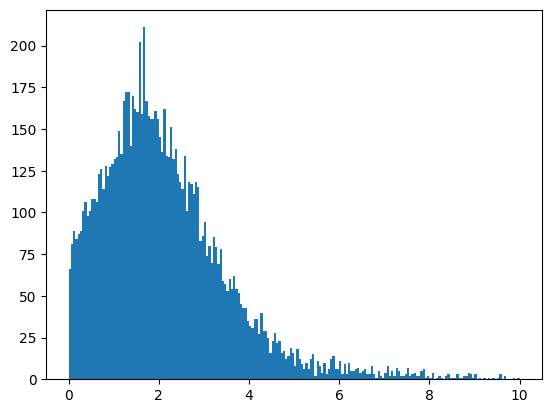

In [34]:
plt.hist(s2_areas.areas, bins=200, range=(0, 10));

# Check first set results

In [24]:
from RaTag.io.file_ops import load_s2areas, load_s2areas_from_path, load_npz_arrays
set0 = run.alpha_sets[0]

In [21]:
runm.sets[0]

SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN34_EL15k/FieldScan_Gate0120_Anode0720
  filenames = <50 files, 47200 waveforms, FastFrame(944 frames/file)>
  multiiso = True
  target_isotope = Th228
  ff = True
  nframes = 944
  gate = 120
  anode = 720
  drift_field = 250.0
  EL_field = 15000.0
  red_drift_field = 1.025
  red_EL_field = 61.508
  speed_drift = 1.329
  time_drift = 3.611
  t_s1 = -4.781
  t_s1_std = 0.653
  t_s2_start = -0.81
  t_s2_start_std = 1.708
  t_s2_end = 4.961
  t_s2_end_std = 2.743
  n_areas_recoil = 49350
  area_s2_mean = 3.125
  area_s2_sigma = 0.307
  area_s2_ci95 = 0.064
  area_s2_fit_success = True
  s2_background_bound = 2.85

  Missing:
    sampling_rate, diffusion_coefficient, baseline_median, baseline_std, filtered_drift_time

In [9]:
load_s2areas_from_path('/Volumes/KINGSTON/RaTag_data/processed/RUN34_EL15k/s2_areas/FieldScan_Gate0120_Anode0720_s2_areas.npz')

S2Areas(uids=array([1296685184, 1296685185, 1296685186, ..., 1296686168, 1296686169,
       1296686170]), areas=array([0.64864804, 4.15286601, 0.05776656, ..., 0.01575344, 0.080996  ,
       0.        ]))

In [18]:
path = '/Volumes/KINGSTON/RaTag_data/processed/RUN34_EL15k/alpha_energies/FieldScan_Gate0120_Anode0720_alpha_energies.npz'
alpha_data = load_npz_arrays(set0, 'alpha_energies')
len(alpha_data['uids'])

  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN34_EL15k/alpha_energies/FieldScan_Gate0120_Anode0720_alpha_energies.npz


49350

In [ ]:
s2_areas = load_s2areas(set0)
s2_areas.uids

# plt.hist(s2_areas.areas, bins=100, range=(0.5, 7));

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN34_EL15k/s2_areas/FieldScan_Gate0768_Anode1368_s2_areas.npz


array([1296685312, 1296685313, 1296685314, ..., 1296686296, 1296686297,
       1296686298])

In [27]:
set_pmt = run.sets[0]
set_alpha = run.alpha_sets[0]
set_pmt.name, set_alpha.name

('FieldScan_Gate0120_Anode0720', 'FieldScan_Gate0120_Anode0720')

In [39]:
pmt_arrays = load_npz_arrays(set_pmt, 's2_areas')
alpha_arrays = load_npz_arrays(set_alpha, 'alpha_energies')

# 2. Safely merge on UIDs
df_pmt = pd.DataFrame(pmt_arrays).drop_duplicates(subset=['uids'])
df_alpha = pd.DataFrame(alpha_arrays).drop_duplicates(subset=['uids'])
df_merged = pd.merge(df_pmt, df_alpha, on='uids', how='inner')

spawned_data = []
for isotope, (e_min, e_max) in set_alpha.isotope_ranges_V.items():
    mask = (df_merged['energies'] >= e_min) & (df_merged['energies'] <= e_max)
    df_iso = df_merged[mask]

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN34_EL15k/s2_areas/FieldScan_Gate0120_Anode0720_s2_areas.npz
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN34_EL15k/alpha_energies/FieldScan_Gate0120_Anode0720_alpha_energies.npz


In [37]:
# pmt_arrays, alpha_arrays
set_alpha.isotope_ranges_E

{'Th228': [5.325, 5.478],
 'Ra224': [5.647, 5.796],
 'Bi212': [6.088, 6.288],
 'Rn220': [6.351, 6.47],
 'Po216': [6.851, 6.962],
 'Po212': [8.709, 8.862]}

In [40]:
df_iso

,s2_areas,uids,energies
39,0.174782,1296685223,7.180863
42,2.355768,1296685226,7.127037
102,0.273628,1296685286,7.127354
106,1.670295,1296685290,7.120952
130,0.804505,1296685314,7.100596
162,1.386168,1296685346,7.093745
213,0.483556,1296685397,7.079062
226,0.499997,1296685410,7.114605
290,0.267439,1296685474,7.114424
327,1.944675,1296685511,7.156212
